In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
data = pd.read_csv("/content/drive/MyDrive/Statistic/weight-height.csv")
data

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [7]:
male_h = data[data["Gender"] == "Male"]["Height"]
female_h = data[data["Gender"] == "Female"]["Height"]

In [8]:
m_count, m_devision = np.histogram(male_h, bins=100)
f_count, f_devision = np.histogram(female_h, bins=100)

In [9]:
m_count

array([  1,   0,   0,   0,   1,   0,   0,   3,   2,   3,   1,   5,   5,
         4,   6,   5,   8,   9,   9,  12,  14,   9,  16,  16,  19,  29,
        34,  27,  20,  37,  47,  56,  60,  63,  59,  70,  77,  78,  88,
        89,  96, 101, 125, 131, 127, 129, 148, 148, 150, 135, 122, 168,
       145, 139, 151, 134, 124, 112, 144,  93, 133, 109,  98, 115, 113,
       103,  83,  79,  62,  61,  46,  50,  40,  43,  42,  34,  28,  30,
        16,  20,  13,  11,   8,  11,   5,   8,   4,   7,   8,   4,   3,
         1,   3,   0,   0,   1,   0,   2,   1,   1])

In [10]:
f_count

array([  1,   1,   0,   1,   1,   1,   0,   3,   2,   7,   0,   4,   4,
         8,   8,  11,   7,   9,  16,  12,  17,  20,  28,  24,  30,  26,
        37,  37,  45,  49,  71,  48,  68,  92,  89,  77,  92,  97, 108,
       111, 127, 129, 115, 135, 146, 130, 135, 133, 124, 152, 148, 130,
       131, 142, 138, 120, 129, 123,  97, 108,  93,  93, 116,  91,  83,
        72,  64,  65,  64,  43,  47,  43,  42,  34,  18,  27,  21,  21,
        21,  17,  11,  11,   9,   5,   9,  10,   4,   3,   2,   1,   1,
         0,   1,   1,   2,   0,   0,   0,   0,   1])

In [13]:
stats.kstest(m_count,f_count)

KstestResult(statistic=np.float64(0.05), pvalue=np.float64(0.9996892272702655), statistic_location=np.int64(63), statistic_sign=np.int8(1))

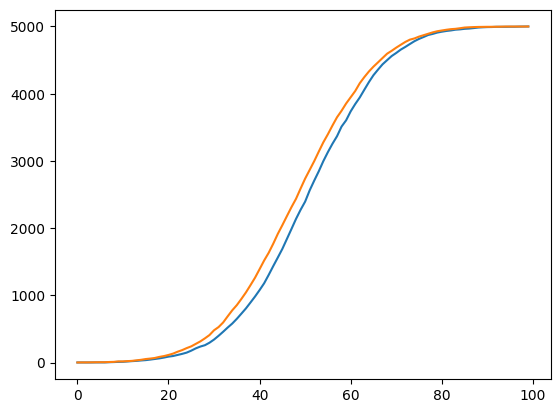

In [16]:
plt.plot(np.cumsum(m_count))
plt.plot(np.cumsum(f_count))

In [23]:
stats.kstest(male_h.sort_values().reset_index(drop=True), female_h.sort_values().reset_index(drop=True), N = 1000)

KstestResult(statistic=np.float64(0.6664), pvalue=np.float64(0.0), statistic_location=np.float64(66.4496081900473), statistic_sign=np.int8(-1))

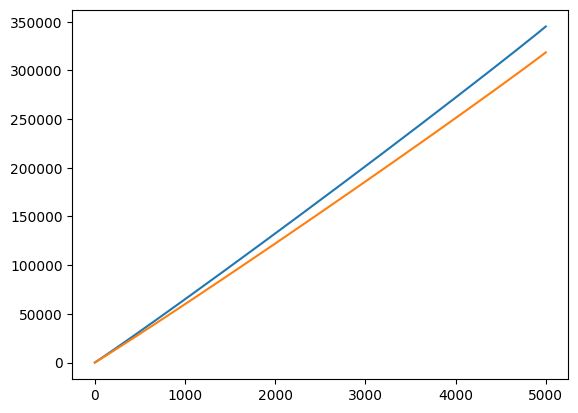

In [24]:
plt.plot(np.cumsum(male_h.sort_values().reset_index(drop=True)))
plt.plot(np.cumsum(female_h.sort_values().reset_index(drop=True)))

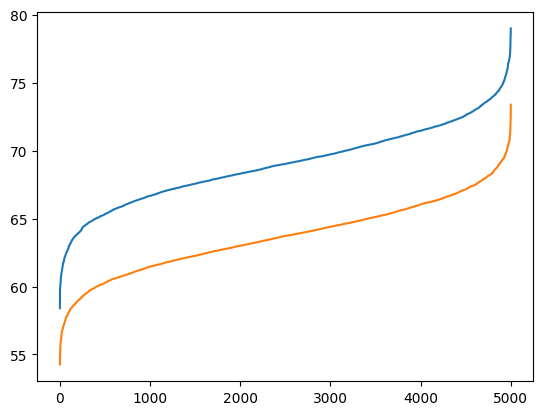

In [25]:
plt.plot((male_h.sort_values().reset_index(drop=True)))
plt.plot((female_h.sort_values().reset_index(drop=True)))

<function matplotlib.pyplot.show(close=None, block=None)>

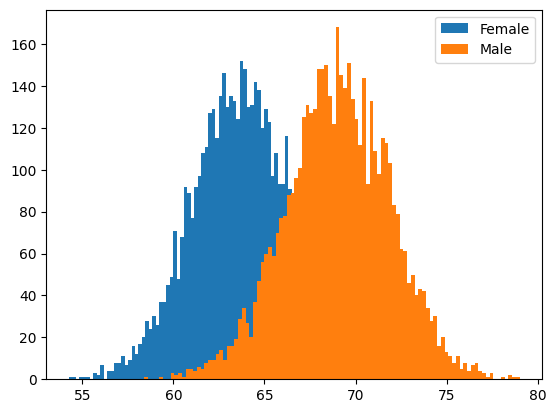

In [28]:
plt.hist(female_h.sort_values().reset_index(drop=True),label = "Female", bins=100)
plt.hist(male_h.sort_values().reset_index(drop=True),label = "Male", bins=100)
plt.legend()
plt.show

In [29]:
print(f"Man's Height mean: {male_h.mean()}")
print(f"Woman's Height mean: {female_h.mean()}")

Man's Height mean: 69.02634590621741
Woman's Height mean: 63.70877360342507


In [30]:
nmale = male_h - male_h.mean()
nfemale = female_h - female_h.mean()
print(nmale)
print(nfemale)

0       4.820671
1      -0.244442
2       5.083759
3       2.704632
4       0.855450
          ...   
4995   -0.166283
4996   -0.052923
4997   -2.012551
4998    2.531373
4999    1.325534
Name: Height, Length: 5000, dtype: float64
5000   -4.798042
5001    1.521239
5002   -0.339770
5003    0.771224
5004   -1.915677
          ...   
9995    2.463879
9996    3.358381
9997    0.159219
9998    5.325470
9999   -1.764528
Name: Height, Length: 5000, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

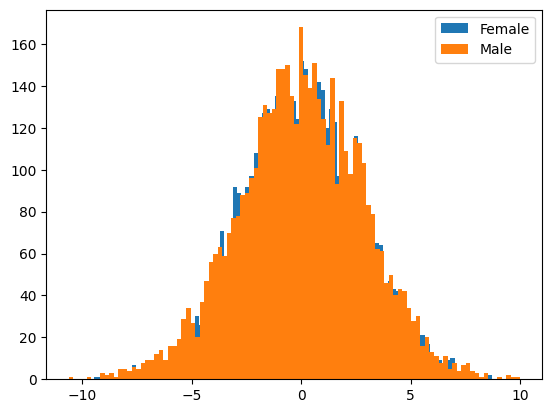

In [32]:
plt.hist(nfemale.sort_values().reset_index(drop=True),label = "Female", bins=100)
plt.hist(nmale.sort_values().reset_index(drop=True),label = "Male", bins=100)
plt.legend()
plt.show

In [33]:
stats.kstest(nmale, nfemale)

KstestResult(statistic=np.float64(0.0194), pvalue=np.float64(0.3035775745288207), statistic_location=np.float64(-3.1687685213965153), statistic_sign=np.int8(1))

In [34]:
stats.kstest(nmale, "norm")

KstestResult(statistic=np.float64(0.2380852585897515), pvalue=np.float64(7.336270444284483e-250), statistic_location=np.float64(1.7244342288191916), statistic_sign=np.int8(-1))

In [37]:
ideal = stats.norm.rvs(loc=nmale.mean(), scale=nmale.std(), size=len(nmale))

In [38]:
stats.kstest(nmale, ideal)

KstestResult(statistic=np.float64(0.0176), pvalue=np.float64(0.42096355203665886), statistic_location=np.float64(0.2182944724569893), statistic_sign=np.int8(1))